# 🛍️ Shopping Mall Customer Segmentation
## Member 4 — Deep Learning: Autoencoder + K-Means

---
### 📌 How Autoencoder Clustering Works (Simple Explanation)

An **Autoencoder** is a neural network that:
1. **Compresses** customer data into a smaller representation (Encoder)
2. **Reconstructs** the original data from that smaller version (Decoder)
3. By forcing the network to compress and reconstruct, it learns the most **meaningful patterns** in the data

```
Original data (4 features)
       ↓
  [ENCODER Neural Network]   ← learns to compress
       ↓
  Latent Space (2 features)  ← compressed meaningful representation
       ↓
  [DECODER Neural Network]   ← learns to reconstruct
       ↓
  Reconstructed data (4 features)
```

Then we run **K-Means on the Latent Space** — this gives much better clusters
because the latent space only contains the most important patterns.

### 📌 Yes, this uses EPOCHS!
Unlike K-Means/DBSCAN/MeanShift, the Autoencoder is a neural network —
it learns by seeing the data many times (epochs).
Each epoch = one complete pass through all training data.
More epochs → better compression → better clusters.

> ⚠️ Run `step0_eda_preprocessing.ipynb` first!
> Install TensorFlow: `pip install tensorflow`

---
## Step 1: Import Libraries & Load Data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from joblib import dump, load
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# TensorFlow for deep learning
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version: {tf.__version__}')

X_scaled = np.load('X_scaled.npy')
df_clean = pd.read_csv('data_preprocessed.csv')
df       = pd.read_csv('Shopping_Mall_Customer_Segmentation_Data_.csv')

scaler = StandardScaler()
scaler.fit(df_clean)

print('✅ Data loaded')
print(f'   Customers : {len(df_clean):,}')
print(f'   Features  : {X_scaled.shape[1]}')

TensorFlow version: 2.21.0
✅ Data loaded
   Customers : 15,079
   Features  : 4


---
## Step 2: Build the Autoencoder

### 📌 Autoencoder Architecture
```
Input  (4)  →  Dense(32)  →  Dense(16)  →  Latent(2)
                                                ↓
Output (4)  ←  Dense(16)  ←  Dense(32)  ←  Dense(2)
              (Decoder)                   (Encoder)
```
- **Latent size = 2**: We compress 4 features into 2
- This forces the network to keep only the MOST IMPORTANT information
- The 2D latent space is then clustered using K-Means

In [22]:
INPUT_DIM  = X_scaled.shape[1]  # 4 features
LATENT_DIM = 2                   # compress to 2 dimensions

# ----- ENCODER -----
inputs      = Input(shape=(INPUT_DIM,), name='Input_Layer')
encoded     = Dense(32, activation='relu', name='Encoder_1')(inputs)
encoded     = Dense(16, activation='relu', name='Encoder_2')(encoded)
latent      = Dense(LATENT_DIM, activation='linear', name='Latent_Space')(encoded)

# ----- DECODER -----
decoded     = Dense(16, activation='relu', name='Decoder_1')(latent)
decoded     = Dense(32, activation='relu', name='Decoder_2')(decoded)
outputs     = Dense(INPUT_DIM, activation='linear', name='Output_Layer')(decoded)

# Build full autoencoder
autoencoder = Model(inputs, outputs, name='Autoencoder')

# Build encoder only (for getting latent representations)
encoder     = Model(inputs, latent, name='Encoder')

autoencoder.compile(optimizer='adam', loss='mse')

print('Autoencoder Architecture:')
autoencoder.summary()
print()
print('📌 The encoder compresses 4 features → 2 (latent space)')
print('   The decoder reconstructs 2 → 4 (original features)')
print('   Training goal: minimise reconstruction error (MSE)')

Autoencoder Architecture:


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_1 (Dense)               │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_2 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_1 (Dense)               │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_2 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,446 (5.65 KB)

 Trainable params: 1,446 (5.65 KB)

 Non-trainable params: 0 (0.00 B)


📌 The encoder compresses 4 features → 2 (latent space)
   The decoder reconstructs 2 → 4 (original features)
   Training goal: minimise reconstruction error (MSE)


---
## Step 3: Train the Autoencoder

### 📌 What happens during training?
- Each **epoch** = the network sees ALL 15,079 customers once
- It tries to compress → reconstruct → compare → adjust weights
- After many epochs, it gets very good at compression
- **EarlyStopping** stops training when improvement plateaus (prevents overfitting)

In [23]:
EPOCHS     = 100
BATCH_SIZE = 256

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,          # stop if no improvement for 10 epochs
    restore_best_weights=True,
    verbose=1
)

print(f'Training Autoencoder for up to {EPOCHS} epochs...')
print(f'Batch size: {BATCH_SIZE}')
print('EarlyStopping: will stop early if validation loss stops improving.')
print()

history = autoencoder.fit(
    X_scaled, X_scaled,      # input = output (reconstruction task)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,    # 10% for validation
    callbacks=[early_stop],
    verbose=1
)

print(f'\n✅ Training complete! Stopped at epoch {len(history.history["loss"])}')

Training Autoencoder for up to 100 epochs...
Batch size: 256
EarlyStopping: will stop early if validation loss stops improving.

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8635 - val_loss: 0.6766
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5609 - val_loss: 0.4833
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4349 - val_loss: 0.3942
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3567 - val_loss: 0.3235
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3087 - val_loss: 0.2848
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2783 - val_loss: 0.2644
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2568 - val_loss: 0.2481
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2413 - val_loss: 0.2389
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2276 - val_loss: 0.2248
Epoch 10/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2126 - val_loss: 0.2093
Epoch 11/100
54/54 ━

---
## Step 4: Plot Training Loss

### 📌 Why check training loss?
Loss shows how well the autoencoder learned to compress and reconstruct.
- Decreasing loss = model is learning
- Training and validation loss should both decrease
- If validation loss increases but training loss decreases = overfitting

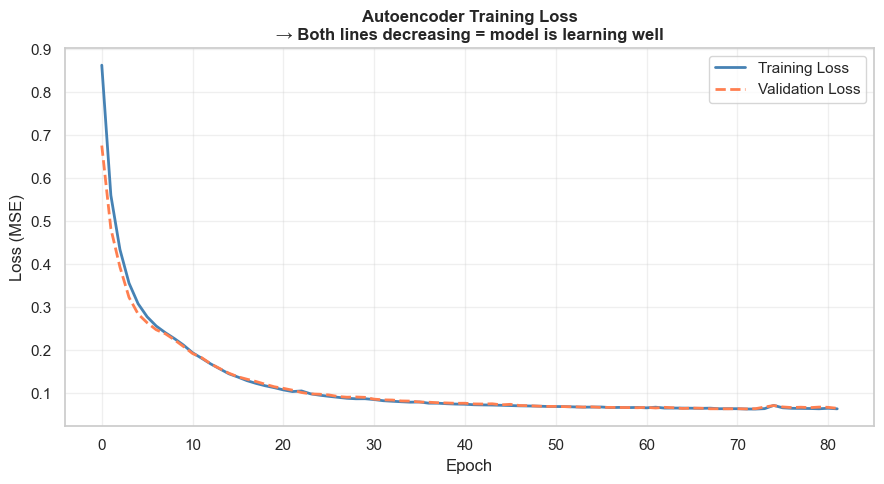

📊 Interpretation:
   → Both training and validation loss should decrease.
   → If both converge = good compression learned.
   → If validation rises while training drops = overfitting (use more EarlyStopping patience).


In [24]:
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='coral',     linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Autoencoder Training Loss\n→ Both lines decreasing = model is learning well', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('autoencoder_loss.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   → Both training and validation loss should decrease.')
print('   → If both converge = good compression learned.')
print('   → If validation rises while training drops = overfitting (use more EarlyStopping patience).')

---
## Step 5: Extract Latent Space Representation

### 📌 What is the latent space?
After training, we pass all customer data through the ENCODER ONLY.
The output is the compressed 2D representation of each customer.
This latent space captures the most important patterns for distinguishing customers.

Original data shape  : (15079, 4)  (4 features)
Latent space shape   : (15079, 2)   (2 features — compressed!)

Latent space sample (first 5 customers):
   Latent_1  Latent_2
0    2.0032    0.7370
1   -0.1386    1.9803
2   -1.1583   -0.4041
3    1.1808   -2.7122
4    2.3076    0.5374

📌 These 2 values per customer capture all the important patterns
   that distinguish customer types. We now cluster these!


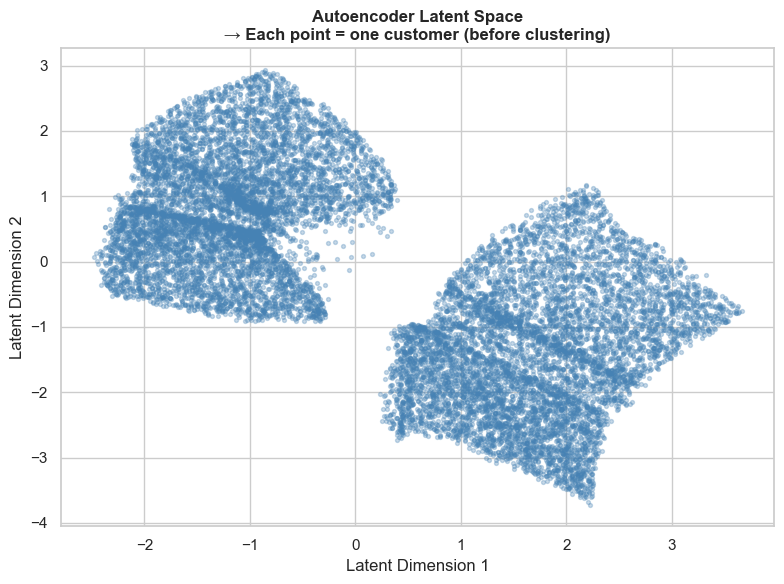

📊 Natural groupings visible in latent space = autoencoder learned meaningful patterns.


In [25]:
X_latent = encoder.predict(X_scaled, verbose=0)
print(f'Original data shape  : {X_scaled.shape}  (4 features)')
print(f'Latent space shape   : {X_latent.shape}   (2 features — compressed!)')
print()
print('Latent space sample (first 5 customers):')
print(pd.DataFrame(X_latent[:5], columns=['Latent_1', 'Latent_2']).round(4))
print()
print('📌 These 2 values per customer capture all the important patterns')
print('   that distinguish customer types. We now cluster these!')

# Visualise the latent space
plt.figure(figsize=(8, 6))
plt.scatter(X_latent[:, 0], X_latent[:, 1], alpha=0.3, s=8, color='steelblue')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Autoencoder Latent Space\n→ Each point = one customer (before clustering)', fontweight='bold')
plt.tight_layout()
plt.savefig('autoencoder_latent.png', bbox_inches='tight')
plt.show()
print('📊 Natural groupings visible in latent space = autoencoder learned meaningful patterns.')

---
## Step 6: Cluster the Latent Space with K-Means

In [26]:
# Find optimal K on latent space
sil_scores = []
K_range    = range(2, 11)

print('Finding optimal K for latent space...')
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_latent)
    sil = silhouette_score(X_latent, lbl)
    sil_scores.append(sil)
    print(f'  K={k}  Silhouette={sil:.4f}')

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f'\n✅ Best K = {best_k}')

# Train final K-Means on latent space
km_latent      = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_latent.fit_predict(X_latent)

df_clean['Cluster'] = cluster_labels
df['Cluster']       = cluster_labels

print(f'\nCluster Distribution:')
for c, count in zip(*np.unique(cluster_labels, return_counts=True)):
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {c}: {count:5,} ({pct:.1f}%) {bar}')

Finding optimal K for latent space...
  K=2  Silhouette=0.6189
  K=3  Silhouette=0.5204
  K=4  Silhouette=0.4152
  K=5  Silhouette=0.3945
  K=6  Silhouette=0.3989
  K=7  Silhouette=0.3615
  K=8  Silhouette=0.3801
  K=9  Silhouette=0.3732
  K=10  Silhouette=0.3748

✅ Best K = 2

Cluster Distribution:
  Cluster 0: 7,484 (49.6%) ████████████████████████
  Cluster 1: 7,595 (50.4%) █████████████████████████


---
## Step 7: Evaluate the Model

In [19]:
sil = silhouette_score(X_latent, cluster_labels)
dbi = davies_bouldin_score(X_latent, cluster_labels)

# Reconstruction error
X_reconstructed = autoencoder.predict(X_scaled, verbose=0)
recon_error     = np.mean(np.square(X_scaled - X_reconstructed))

print('=' * 55)
print('   AUTOENCODER + K-MEANS EVALUATION METRICS')
print('=' * 55)
print(f'  Deep Learning Model  : Autoencoder')
print(f'  Epochs Trained       : {len(history.history["loss"])}')
print(f'  Reconstruction Error : {recon_error:.6f}  (lower = better compression)')
print(f'  Latent Dimensions    : {LATENT_DIM}')
print(f'  Clusters (K-Means)   : {best_k}')
print(f'  Silhouette Score     : {sil:.4f}  (closer to 1 = better)')
print(f'  Davies-Bouldin Index : {dbi:.4f}  (closer to 0 = better)')
print('=' * 55)

scores = {'algorithm': 'Autoencoder+KMeans', 'n_clusters': best_k,
          'silhouette': round(sil, 4), 'davies_bouldin': round(dbi, 4),
          'inertia': round(km_latent.inertia_, 2), 'noise': 0,
          'recon_error': round(recon_error, 6)}
pickle.dump(scores,        open('autoencoder_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('autoencoder_labels.pkl', 'wb'))
print('\n✅ Scores saved.')

   AUTOENCODER + K-MEANS EVALUATION METRICS
  Deep Learning Model  : Autoencoder
  Epochs Trained       : 86
  Reconstruction Error : 0.075670  (lower = better compression)
  Latent Dimensions    : 2
  Clusters (K-Means)   : 2
  Silhouette Score     : 0.5564  (closer to 1 = better)
  Davies-Bouldin Index : 0.7014  (closer to 0 = better)

✅ Scores saved.


---
## Step 8: Visualise Clusters — Latent Space + 3D Original Space

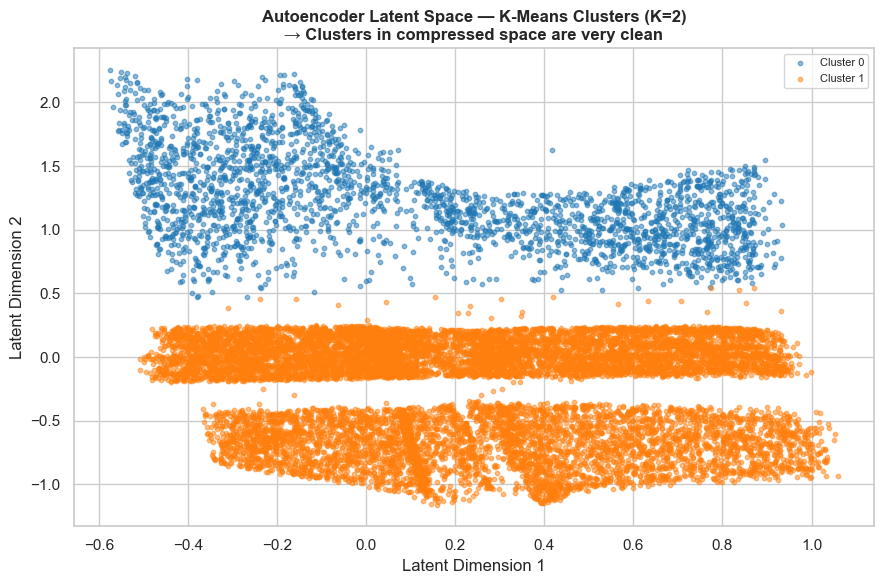

📊 Latent space clusters are cleaner than raw-feature clustering
   because the autoencoder removes noise and focuses on key patterns.


In [20]:
palette = sns.color_palette('tab10', best_k)

# --- Latent space cluster plot ---
plt.figure(figsize=(9, 6))
for c in range(best_k):
    mask = cluster_labels == c
    plt.scatter(X_latent[mask, 0], X_latent[mask, 1],
                color=palette[c], label=f'Cluster {c}', alpha=0.5, s=10)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title(f'Autoencoder Latent Space — K-Means Clusters (K={best_k})\n→ Clusters in compressed space are very clean',
          fontweight='bold')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('autoencoder_latent_clusters.png', bbox_inches='tight')
plt.show()
print('📊 Latent space clusters are cleaner than raw-feature clustering')
print('   because the autoencoder removes noise and focuses on key patterns.')

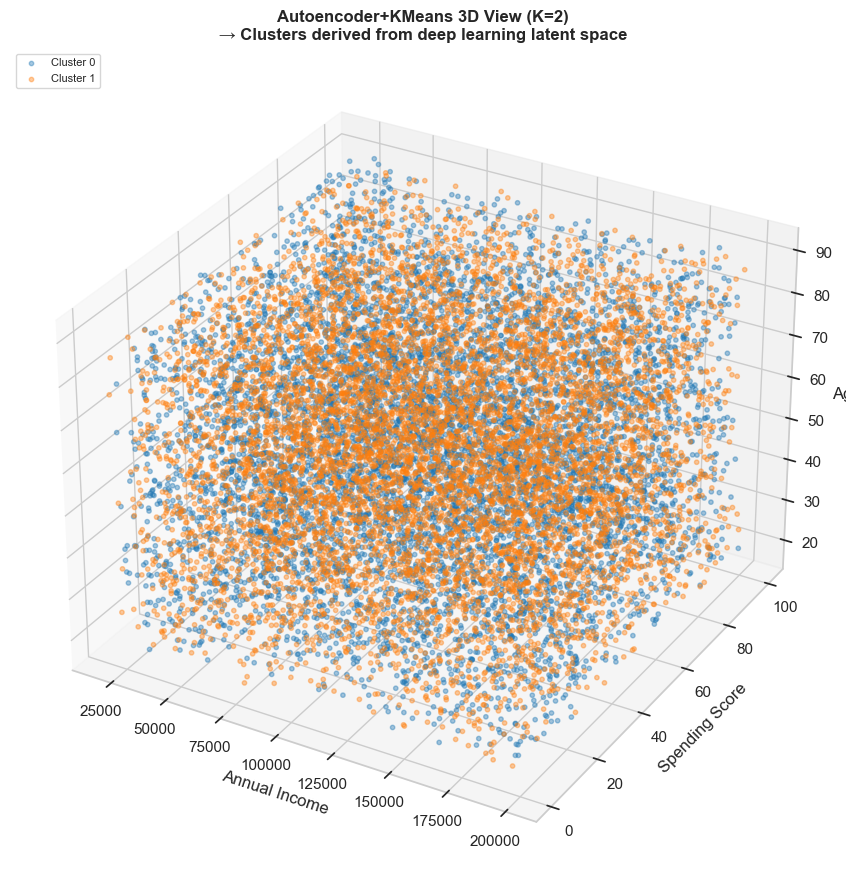

In [9]:
# --- 3D original feature plot coloured by cluster ---
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

for c in range(best_k):
    mask = cluster_labels == c
    ax.scatter(
        df.loc[mask, 'Annual Income'],
        df.loc[mask, 'Spending Score'],
        df.loc[mask, 'Age'],
        color=palette[c], label=f'Cluster {c}', alpha=0.4, s=10
    )

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title(f'Autoencoder+KMeans 3D View (K={best_k})\n→ Clusters derived from deep learning latent space',
             fontweight='bold')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('autoencoder_3d.png', bbox_inches='tight')
plt.show()

---
## Step 9: Cluster Profile Analysis

=== Cluster Profiles (Mean Values) ===
          Age  Annual Income  Spending Score  Count  % of Total
Cluster                                                        
0        54.1       109902.8            50.4   7484        49.6
1        54.2       109585.3            50.8   7595        50.4


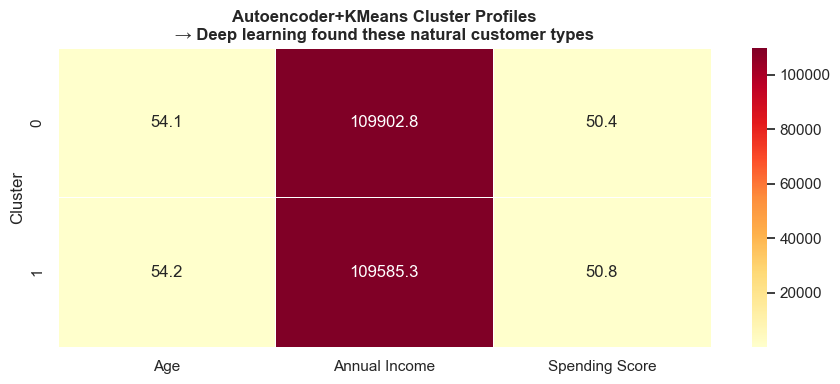

In [10]:
profile = df.groupby('Cluster')[['Age','Annual Income','Spending Score']].mean().round(1)
profile['Count']      = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(1)
print('=== Cluster Profiles (Mean Values) ===')
print(profile)

plt.figure(figsize=(9, 4))
heatmap_data = df.groupby('Cluster')[['Age','Annual Income','Spending Score']].mean()
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Autoencoder+KMeans Cluster Profiles\n→ Deep learning found these natural customer types',
          fontweight='bold')
plt.tight_layout()
plt.savefig('autoencoder_heatmap.png', bbox_inches='tight')
plt.show()

---
## Step 10: Save Models & Predict New Customer

In [11]:
# Save autoencoder (TensorFlow format)
autoencoder.save('autoencoder_model.keras')
encoder.save('encoder_model.keras')

# Save K-Means trained on latent space
dump(km_latent, 'autoencoder_kmeans.joblib')

print('✅ Saved: autoencoder_model.keras')
print('✅ Saved: encoder_model.keras')
print('✅ Saved: autoencoder_kmeans.joblib')

✅ Saved: autoencoder_model.keras
✅ Saved: encoder_model.keras
✅ Saved: autoencoder_kmeans.joblib


In [12]:
# Load models
encoder_loaded  = tf.keras.models.load_model('encoder_model.keras')
kmeans_loaded   = load('autoencoder_kmeans.joblib')

cluster_names = {
    0: 'Budget-Conscious Customers',
    1: 'VIP / High Spenders',
    2: 'Average Customers',
    3: 'Impulsive Buyers',
}  # Update based on your profiles!

print('=== Enter New Customer Details ===')
input_age            = int(input('Enter Age              : '))
input_gender         = input('Enter Gender (Male/Female): ').strip().capitalize()
input_annual_income  = float(input('Enter Annual Income    : '))
input_spending_score = float(input('Enter Spending Score (1-100): '))

gender_encoded      = 0 if input_gender == 'Female' else 1
new_customer        = np.array([[input_age, gender_encoded, input_annual_income, input_spending_score]])
new_customer_scaled = scaler.transform(new_customer)

# Step 1: Encode to latent space
new_latent = encoder_loaded.predict(new_customer_scaled, verbose=0)

# Step 2: Cluster the latent representation
predicted_cluster = kmeans_loaded.predict(new_latent)[0]

print()
print('=' * 50)
print('         PREDICTION RESULT')
print('=' * 50)
print(f'  Latent Representation : {new_latent[0].round(4)}')
print(f'  Predicted Cluster     : {predicted_cluster}')
print(f'  Segment Name          : {cluster_names.get(predicted_cluster, "Segment " + str(predicted_cluster))}')
cluster_avg = df[df['Cluster'] == predicted_cluster][['Age','Annual Income','Spending Score']].mean()
print(f'  Cluster Avg Age       : {cluster_avg["Age"]:.0f}')
print(f'  Cluster Avg Income    : {cluster_avg["Annual Income"]:,.0f}')
print(f'  Cluster Avg Score     : {cluster_avg["Spending Score"]:.0f}')
print('=' * 50)
print()
print('📌 How this prediction works:')
print('   1. New customer data was scaled (same as training)')
print('   2. Encoder compressed it into 2 latent values')
print('   3. K-Means assigned it to the nearest cluster in latent space')

=== Enter New Customer Details ===

         PREDICTION RESULT
  Latent Representation : [ 0.907  -1.1237]
  Predicted Cluster     : 1
  Segment Name          : VIP / High Spenders
  Cluster Avg Age       : 54
  Cluster Avg Income    : 109,585
  Cluster Avg Score     : 51

📌 How this prediction works:
   1. New customer data was scaled (same as training)
   2. Encoder compressed it into 2 latent values
   3. K-Means assigned it to the nearest cluster in latent space
